In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [6]:
df = pd.read_csv('survey_results_slim.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48019 entries, 0 to 48018
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   MainBranch                      48019 non-null  object 
 1   Age                             48019 non-null  object 
 2   Employment                      48007 non-null  object 
 3   RemoteWork                      47940 non-null  object 
 4   EdLevel                         48019 non-null  object 
 5   LearnCode                       47935 non-null  object 
 6   LearnCodeOnline                 38414 non-null  object 
 7   YearsCode                       47950 non-null  object 
 8   YearsCodePro                    47825 non-null  object 
 9   DevType                         47904 non-null  object 
 10  OrgSize                         47982 non-null  object 
 11  Country                         48019 non-null  object 
 12  LanguageHaveWorkedWith          

In [8]:
#calculate missing percentage
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("Missing data percentage:\n", missing_pct[missing_pct > 50])
print("\nTotal columns with more than 50% missing data:", (missing_pct > 50).sum())

Missing data percentage:
 AIDevHaveWorkedWith      70.969824
AIToolCurrently Using    59.286949
dtype: float64

Total columns with more than 50% missing data: 2


In [9]:
#get columns with >50% missing 
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()

#add all column to drop in one consolidated list
cols_to_drop.extend([
    #less critical columns
     'LearnCodeOnline', 'OpSysPersonal use',

    #meta columns
     'ICorPM', 'ProfessionalTech', 'TBranch',

      # High missingness tech columns
    'AISearchHaveWorkedWith',  # 38.6% missing
    'MiscTechHaveWorkedWith',  # 33.8% missing
    
    # Office tools - less relevant
    'OfficeStackAsyncHaveWorkedWith',
    'OfficeStackSyncHaveWorkedWith',
    'NEWCollabToolsHaveWorkedWith'

])

#remove duplicates and drop
cols_to_drop = list(set(cols_to_drop))
df_cleaned =df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns")
print(f"Remaining columns: {df_cleaned.shape[1]}")
print(f"\nRemainig columns\n: {df_cleaned.columns}")

Dropped 12 columns
Remaining columns: 21

Remainig columns
: Index(['MainBranch', 'Age', 'Employment', 'RemoteWork', 'EdLevel', 'LearnCode',
       'YearsCode', 'YearsCodePro', 'DevType', 'OrgSize', 'Country',
       'LanguageHaveWorkedWith', 'DatabaseHaveWorkedWith',
       'PlatformHaveWorkedWith', 'WebframeHaveWorkedWith',
       'ToolsTechHaveWorkedWith', 'OpSysProfessional use', 'AISelect',
       'WorkExp', 'Industry', 'ConvertedCompYearly'],
      dtype='object')


In [10]:
df_cleaned.head()

,MainBranch,Age,Employment,RemoteWork,EdLevel,LearnCode,YearsCode,YearsCodePro,DevType,OrgSize,...,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,ToolsTechHaveWorkedWith,OpSysProfessional use,AISelect,WorkExp,Industry,ConvertedCompYearly
0,I am a developer by profession,25-34 years old,"Employed, full-time",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;Friend or fam...,18,9,"Senior Executive (C-Suite, VP, etc.)",2 to 9 employees,...,HTML/CSS;JavaScript;Python,Supabase,Amazon Web Services (AWS);Netlify;Vercel,Next.js;React;Remix;Vue.js,Docker;Kubernetes;npm;Pip;Vite;Webpack;Yarn,MacOS;Windows;Windows Subsystem for Linux (WSL),Yes,10.0,"Information Services, IT, Software Development...",285000.0
1,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,27,23,"Developer, back-end","5,000 to 9,999 employees",...,Bash/Shell (all shells);Go,NaN,Amazon Web Services (AWS);Google Cloud;OpenSta...,NaN,Cargo;Docker;Kubernetes;Make;Nix,MacOS;Other Linux-based,"No, and I don't plan to",23.0,"Information Services, IT, Software Development...",250000.0
2,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)","Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Colleague;Friend or family member;Other online...,12,7,"Developer, front-end",100 to 499 employees,...,Bash/Shell (all shells);HTML/CSS;JavaScript;PH...,PostgreSQL;Redis,Cloudflare;Heroku,Node.js;React;Ruby on Rails;Vue.js;WordPress,Homebrew;npm;Vite;Webpack;Yarn,iOS;iPadOS;MacOS,"No, and I don't plan to",7.0,NaN,156000.0
3,I am a developer by profession,25-34 years old,"Employed, full-time;Independent contractor, fr...",Remote,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Online Courses or Certi...,6,4,"Developer, full-stack",20 to 99 employees,...,HTML/CSS;JavaScript;TypeScript,BigQuery;Elasticsearch;MongoDB;PostgreSQL,Amazon Web Services (AWS);Firebase;Heroku;Netl...,Express;Gatsby;NestJS;Next.js;Node.js;React,Docker;npm;Webpack;Yarn,Other (Please Specify):,Yes,6.0,Other,23456.0
4,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Some college/university study without earning ...,Books / Physical media;Colleague;Online Course...,21,21,"Developer, back-end",100 to 499 employees,...,Bash/Shell (all shells);HTML/CSS;JavaScript;Ru...,BigQuery;Cloud Firestore;PostgreSQL;Redis,Amazon Web Services (AWS);Cloudflare;Google Cloud,Angular;Express;NestJS;Node.js,Docker;Homebrew;Kubernetes;npm;pnpm;Terraform,MacOS,Yes,22.0,Other,96828.0


In [11]:
# check remaining missing data in the filtered dataset
print("Missing data in remaining columns:")
missing_after = (df_cleaned.isnull().sum() / len(df_cleaned) * 100).sort_values(ascending=False)
print(missing_after[missing_after > 0])     

#check datatypes
print("\nData types:")
print(df_cleaned.dtypes.value_counts())

#Check unique values for some key categorical columns
print("\nUnique values in key columns:")
for col in ['Country', 'DevType', 'EdLevel', 'Employment']:
    if col in df_cleaned.columns:
        print(f"{col}: {df_cleaned[col].nunique()} unique values")


Missing data in remaining columns:
Industry                   42.216623
WorkExp                    32.031071
PlatformHaveWorkedWith     22.166226
WebframeHaveWorkedWith     21.145796
DatabaseHaveWorkedWith     13.026094
ToolsTechHaveWorkedWith     8.255066
OpSysProfessional use       6.224619
YearsCodePro                0.404007
LanguageHaveWorkedWith      0.283221
DevType                     0.239489
LearnCode                   0.174931
RemoteWork                  0.164518
YearsCode                   0.143693
OrgSize                     0.077053
Employment                  0.024990
dtype: float64

Data types:
object     19
float64     2
Name: count, dtype: int64

Unique values in key columns:
Country: 171 unique values
DevType: 33 unique values
EdLevel: 8 unique values
Employment: 14 unique values


In [12]:
# After dropping high missing columns
df_model = df_cleaned.dropna().copy()
print(f"Final dataset shape: {df_model.shape}")
print(f"Rows retained: {len(df_model)} ({len(df_model)/48019*100:.1f}% of filtered data)")

Final dataset shape: (16460, 21)
Rows retained: 16460 (34.3% of filtered data)


In [13]:
# check target variable distribution
print("\nSalary statistics:")
print(df_model['ConvertedCompYearly'].describe())

# Check for outliers
print(f"\nSalary statistics > $500k: {(df_model['ConvertedCompYearly'] > 500000).sum()}")
print(f"Salary < $10k: {(df_model['ConvertedCompYearly'] < 10000).sum()}")


Salary statistics:
count    1.646000e+04
mean     9.412425e+04
std      1.309772e+05
min      1.000000e+00
25%      4.362100e+04
50%      7.496300e+04
75%      1.231530e+05
max      1.031937e+07
Name: ConvertedCompYearly, dtype: float64

Salary statistics > $500k: 51
Salary < $10k: 1100


Top 10 salaries:


,Country,DevType,YearsCodePro,ConvertedCompYearly
2960,United States of America,"Developer, full-stack",9,500000.0
4986,United States of America,Research & Development role,7,500000.0
5332,United States of America,"Senior Executive (C-Suite, VP, etc.)",10,500000.0
16870,United States of America,"Developer, back-end",20,500000.0
18029,United States of America,"Developer, back-end",10,500000.0
38907,United States of America,"Developer, embedded applications or devices",12,500000.0
42475,United States of America,"Developer, back-end",14,500000.0
47995,United States of America,"Senior Executive (C-Suite, VP, etc.)",12,500000.0
6017,Australia,"Developer, back-end",15,495779.0
5049,United States of America,"Developer, back-end",5,490000.0



Bottom 10 salaries:


,Country,DevType,YearsCodePro,ConvertedCompYearly
5207,Nepal,"Developer, back-end",5,10000.0
6601,Syrian Arab Republic,"Developer, front-end",3,10000.0
27775,"Iran, Islamic Republic of...","Developer, desktop or enterprise applications",20,10000.0
28060,Syrian Arab Republic,"Developer, full-stack",6,10000.0
32545,Ecuador,Project manager,4,10000.0
44416,Sri Lanka,"Developer, full-stack",4,10000.0
44769,Somalia,System administrator,3,10000.0
30079,India,Developer Advocate,2,10057.0
34202,Mauritius,"Developer, full-stack",2,10085.0
40776,Malaysia,Data scientist or machine learning specialist,Less than 1 year,10090.0



After salary filtering:
Rows: 15309
Salary range: $10,000 - $500,000

New salary statistics:
count     15309.000000
mean      97043.815925
std       67251.276938
min       10000.000000
25%       50332.000000
50%       80317.000000
75%      128507.000000
max      500000.000000
Name: ConvertedCompYearly, dtype: float64


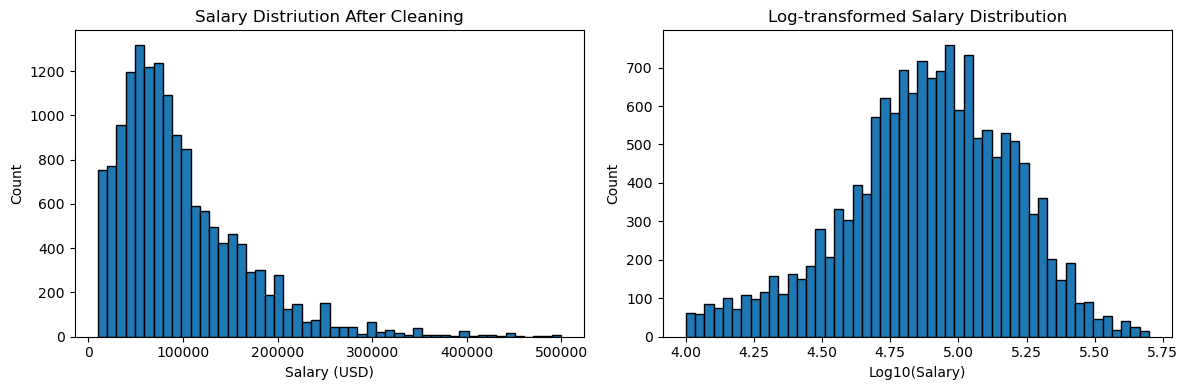

In [33]:
# Check the extreme values
print("Top 10 salaries:")
display(df_model.nlargest(10, 'ConvertedCompYearly')[['Country', 'DevType', 'YearsCodePro', 'ConvertedCompYearly']])

print("\nBottom 10 salaries:")
display(df_model.nsmallest(10, 'ConvertedCompYearly')[['Country', 'DevType', 'YearsCodePro', 'ConvertedCompYearly']])

# Apply reasonable salaries filters
# - Min $10k: Removes part-time/student/hobby responses or data errors
# - Max $500k: Removes extreme outliers while keeping high earners
df_model = df_model[
    (df_model['ConvertedCompYearly'] >= 10000)&
    (df_model['ConvertedCompYearly'] <= 500000)]

print(f"\nAfter salary filtering:")
print(f"Rows: {len(df_model)}")
print(f"Salary range: ${df_model['ConvertedCompYearly'].min():,.0f} - ${df_model['ConvertedCompYearly'].max():,.0f}")
print(f"\nNew salary statistics:")
print(df_model['ConvertedCompYearly'].describe())

# Visualize the distribution
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.hist(df_model['ConvertedCompYearly'], bins=50, edgecolor='black')
plt.xlabel('Salary (USD)')
plt.ylabel('Count')
plt.title('Salary Distriution After Cleaning')

plt.subplot(1, 2, 2)
plt.hist(np.log10(df_model['ConvertedCompYearly']), bins=50, edgecolor='black')
plt.xlabel('Log10(Salary)')
plt.ylabel('Count')
plt.title('Log-transformed Salary Distribution')

plt.tight_layout()
plt.show()

Feature Transformation

In [55]:
# Count features for all tech stack columns
print("Creating count features for all multi-select columns...")

# Languages
df_model['Num_Languages']=df_model['LanguageHaveWorkedWith'].str.count(';') + 1

# Databases
df_model['Num_Databases']=df_model['DatabaseHaveWorkedWith'].str.count(';') + 1

#Platforms
df_model['Num_Platforms']=df_model['PlatformHaveWorkedWith'].str.count(';') + 1

# Webframeworks
df_model['Num_Webframes']=df_model['WebframeHaveWorkedWith'].str.count(';') + 1

#Tools/Tech
df_model['Num_Tools']=df_model['ToolsTechHaveWorkedWith'].str.count(';') + 1

#Check the new features
print("\nCount features statistics:")
count_cols=['Num_Languages', 'Num_Databases', 'Num_Platforms', 'Num_Webframes', 'Num_Tools']
display(df_model[count_cols].describe())

#Create a "Total skills" feature
df_model['Total_Skills']=(
    df_model['Num_languages']+
    df_model['Num_Databases']+
    df_model['Num_Platforms']+
    df_model['Num_Webframes']+
    df_model['Num_Tools'])

print("\nTotal Skills Distribution:")
print(df_model['Total_Skills'].describe())

#Quick correlation check with salary
print("\nCorrelation with salary:")
correlation_data=df_model[count_cols + ['Total_Skills', 'ConvertedCompYearly']].corr()['ConvertedCompYearly'].sort_values(ascending=False)
print(correlation_data)

Creating count features for all multi-select columns...

Count features statistics:


,Num_Languages,Num_Databases,Num_Platforms,Num_Webframes,Num_Tools
count,15309.000000,15309.000000,15309.000000,15309.000000,15309.000000
mean,5.888366,3.409890,2.412698,3.691097,5.575805
std,2.918188,2.176719,1.643505,2.409808,3.192943
min,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,2.000000,1.000000,2.000000,3.000000
50%,5.000000,3.000000,2.000000,3.000000,5.000000
75%,7.000000,4.000000,3.000000,5.000000,7.000000
max,41.000000,30.000000,17.000000,32.000000,37.000000



Total Skills Distribution:
count    15309.000000
mean        20.977856
std          9.170052
min          5.000000
25%         15.000000
50%         19.000000
75%         25.000000
max        140.000000
Name: Total_Skills, dtype: float64

Correlation with salary:
ConvertedCompYearly    1.000000
Num_Tools              0.114356
Num_Languages          0.074025
Total_Skills           0.044754
Num_Platforms          0.006805
Num_Databases         -0.003100
Num_Webframes         -0.072698
Name: ConvertedCompYearly, dtype: float64


In [61]:
# Explore which langages/skills are most common
print("Top 20 languages:")
all_langs=df_model['LanguageHaveWorkedWith'].str.split(';').explode()
print(all_langs.value_counts().head(20))

print("\nTop 15 databases:")
all_langs=df_model['DatabaseHaveWorkedWith'].str.split(';').explode()
print(all_langs.value_counts().head(15))

print("\nTop 15 Platforms")
all_langs=df_model['PlatformHaveWorkedWith'].str.split(';').explode()
print(all_langs.value_counts().head(15))

# After seeing these, we'll create binary features for:
# - High-paying languages (Rust, Go, Scala, etc.)
# - Popular languages (Python, JavaScript, SQL, etc.)
# - Specialized databases (PostgreSQL, MongoDB, etc.)
# - Cloud platforms (AWS, Azure, Google Cloud)

Top 20 languages:
LanguageHaveWorkedWith
JavaScript                 11851
SQL                         9565
HTML/CSS                    9423
TypeScript                  8868
Python                      7193
Bash/Shell (all shells)     6042
C#                          5108
Java                        4645
PHP                         3059
Go                          2840
PowerShell                  2747
C++                         2028
Rust                        1988
C                           1691
Kotlin                      1635
Ruby                        1538
Dart                         909
Lua                          857
Groovy                       758
Swift                        704
Name: count, dtype: int64

Top 15 databases:
DatabaseHaveWorkedWith
PostgreSQL                    8827
MySQL                         6112
Redis                         4865
Microsoft SQL Server          4599
SQLite                        4586
MongoDB                       4273
Elasticsearch        